In [2]:
!pip install transformers datasets evaluate scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00


In [3]:
import json
import torch
import numpy as np
import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

In [4]:
import os

print(os.listdir("/kaggle/input/datasets/susandilinn/dataset"))

['AI3.json', 'AI6.json', 'AI7.json', 'AI5.json', 'AI1.json', '5_robotics_labeled_dataset.json', '1_robotics_labeled_dataset.json', 'AI2.json', 'AI4s.json', '3_robotics_labeled_dataset.json', '2_robotics_labeled_dataset.json']


In [5]:
from datasets import load_dataset

dataset = load_dataset(
    "json",
    data_files="/kaggle/input/datasets/susandilinn/dataset/*.json"
)

dataset

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input', 'label'],
        num_rows: 792
    })
})

In [6]:
dataset = dataset["train"].train_test_split(test_size=0.2, seed=42)

train_dataset = dataset["train"]
test_dataset = dataset["test"]

print(train_dataset)
print(test_dataset)

Dataset({
    features: ['input', 'label'],
    num_rows: 633
})
Dataset({
    features: ['input', 'label'],
    num_rows: 159
})


In [7]:
print(train_dataset.column_names)

['input', 'label']


In [8]:
import pandas as pd

# Convert to pandas for easy inspection
df = pd.DataFrame(train_dataset)

print(df['label'].value_counts())
print("\nPercentage:")
print(df['label'].value_counts(normalize=True) * 100)

label
0    397
1    236
Name: count, dtype: int64

Percentage:
label
0    62.71722
1    37.28278
Name: proportion, dtype: float64


In [9]:
train_dataset = train_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

In [10]:
def convert_labels(example):
    example["labels"] = int(example["labels"])
    return example

train_dataset = train_dataset.map(convert_labels)
test_dataset = test_dataset.map(convert_labels)

Map:   0%|          | 0/633 [00:00<?, ? examples/s]

Map:   0%|          | 0/159 [00:00<?, ? examples/s]

In [11]:
model_name = "bert-base-uncased"
# model_name = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [12]:
def tokenize_function(example):
    return tokenizer(
        example["input"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/633 [00:00<?, ? examples/s]

Map:   0%|          | 0/159 [00:00<?, ? examples/s]

In [13]:
train_dataset = train_dataset.remove_columns(["input"])
test_dataset = test_dataset.remove_columns(["input"])

In [14]:
train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "token_type_ids", "labels"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "token_type_ids", "labels"]
)

In [15]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    auc = roc_auc_score(labels, probs)

    return {
        "accuracy": acc,
        "roc_auc": auc
    }

In [16]:
# training_args = TrainingArguments(
#     output_dir="./results",
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     learning_rate=2e-5,
#     per_device_train_batch_size=8,
#     per_device_eval_batch_size=8,
#     num_train_epochs=3,
#     weight_decay=0.01,
#     logging_dir="./logs",
#     load_best_model_at_end=True
# )

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1.5e-5,        # smaller LR = more stable
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.05,           # stronger regularization
    warmup_ratio=0.1,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="roc_auc",
    greater_is_better=True,
    save_total_limit=2
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [17]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


KeyboardInterrupt: 

In [ ]:
predictions = trainer.predict(test_dataset)

logits = predictions.predictions
labels = predictions.label_ids

probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()

fpr, tpr, thresholds = roc_curve(labels, probs)
auc_score = roc_auc_score(labels, probs)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
custom_threshold = 0.7

custom_preds = (probs >= custom_threshold).astype(int)

accuracy = accuracy_score(labels, custom_preds)

print("Custom Threshold:", custom_threshold)
print("Accuracy:", accuracy)

In [ ]:
trainer.save_model("./my_bert_model")
tokenizer.save_pretrained("./my_bert_model")

## model accuracy 

In [18]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

bert_path = "/kaggle/input/datasets/susandilinn/models/my_bert_model/my_bert_model"

tokenizer = AutoTokenizer.from_pretrained(bert_path)
bert_model = AutoModelForSequenceClassification.from_pretrained(bert_path)

bert_model.to(device)
bert_model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [19]:
from torch.utils.data import DataLoader

test_loader = DataLoader(test_dataset, batch_size=16)

all_logits = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = bert_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits

        all_logits.append(logits.cpu())
        all_labels.append(labels.cpu())

all_logits = torch.cat(all_logits)
all_labels = torch.cat(all_labels)

In [20]:
import numpy as np

probs = torch.softmax(all_logits, dim=1)[:,1].numpy()
preds = np.argmax(all_logits.numpy(), axis=1)
labels = all_labels.numpy()

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(labels, preds)
precision = precision_score(labels, preds)
recall = recall_score(labels, preds)
f1 = f1_score(labels, preds)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.8742138364779874
Precision: 0.7945205479452054
Recall: 0.9206349206349206
F1 Score: 0.8529411764705882


In [22]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(labels, probs)
print("ROC AUC:", auc)

ROC AUC: 0.9264219576719576


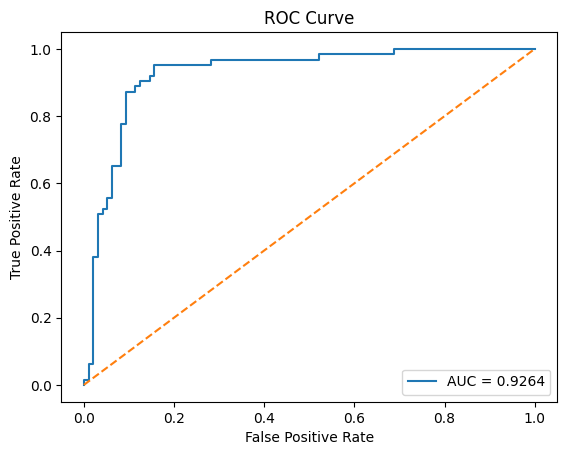

In [24]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(labels, probs)

# Calculate AUC
auc = roc_auc_score(labels, probs)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")  # random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

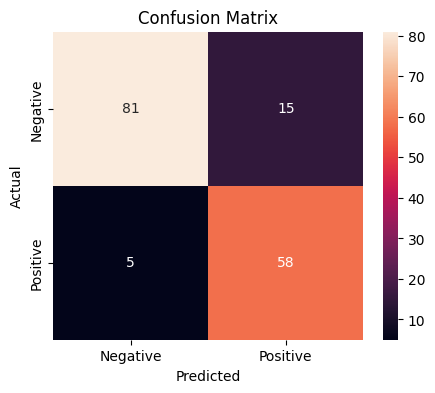

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Negative","Positive"],
            yticklabels=["Negative","Positive"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [26]:
from sklearn.metrics import classification_report

print(classification_report(labels, preds))

              precision    recall  f1-score   support

           0       0.94      0.84      0.89        96
           1       0.79      0.92      0.85        63

    accuracy                           0.87       159
   macro avg       0.87      0.88      0.87       159
weighted avg       0.88      0.87      0.88       159



## testing with pdf files

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_path = "/kaggle/working/my_bert_model"  # your saved model

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

model.to(device)
model.eval()

In [ ]:
!pip install pdfplumber scikit-learn -q

In [ ]:
import re
import pdfplumber
from pathlib import Path

def extract_text_from_pdf(pdf_path):
    all_text = ""
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            page_text = page.extract_text()
            if page_text:
                all_text += page_text + "\n"

    # Remove URLs
    all_text = re.sub(r"http\S+", "", all_text)
    all_text = re.sub(r"www\.\S+", "", all_text)

    return all_text

In [ ]:
def remove_consecutive_duplicates(text):
    lines = text.split("\n")
    cleaned = []
    prev_line = None

    for line in lines:
        stripped = line.strip()
        if stripped == prev_line:
            continue
        cleaned.append(line)
        prev_line = stripped

    return "\n".join(cleaned)


def remove_equation_lines(text):
    cleaned_lines = []

    for line in text.split("\n"):
        stripped = line.strip()

        if not stripped:
            cleaned_lines.append("")
            continue

        math_symbol_ratio = sum(c in "𝜃𝑥𝑦𝑋𝑌𝒚𝜽=∗+-^()⋯" for c in stripped) / len(stripped)

        if math_symbol_ratio > 0.3:
            continue

        if re.fullmatch(r"[0-9\s=+\-*/().]+", stripped):
            continue

        cleaned_lines.append(line)

    return "\n".join(cleaned_lines)


def clean_text_structured(text: str) -> str:
    text = text.replace('\ufeff', '')
    text = re.sub(r'\r\n', '\n', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[•◦▪–—]', '-', text)

    lines = [l.strip() for l in text.split('\n')]

    cleaned = []
    buffer = ""

    for line in lines:
        if not line:
            if buffer:
                cleaned.append(buffer)
                buffer = ""
            cleaned.append("")
            continue

        if line.startswith("-"):
            if buffer:
                cleaned.append(buffer)
                buffer = ""
            cleaned.append(line)
            continue

        if buffer and not re.search(r'[.!?]$', buffer):
            buffer += " " + line
        else:
            if buffer:
                cleaned.append(buffer)
            buffer = line

    if buffer:
        cleaned.append(buffer)

    text = "\n".join(cleaned)
    text = re.sub(r'\n{3,}', '\n\n', text)

    text = remove_consecutive_duplicates(text)
    text = remove_equation_lines(text)

    return text.strip()

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_path = "my_bert_model"  # your trained model folder

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

model.to(device)
model.eval()

In [ ]:
def split_into_sentences(text):
    sentences = re.split(r'(?<=[.!?])\s+', text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 20]
    return sentences

In [ ]:
def score_sentences(sentences, batch_size=16):
    scores = []

    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i+batch_size]

        inputs = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=128
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        probs = torch.softmax(outputs.logits, dim=1)

        for j, sentence in enumerate(batch):
            importance_score = probs[j][1].item()
            scores.append((sentence, importance_score))

    return scores

In [ ]:
def select_top_sentences(scored_sentences, ratio=0.25):
    sorted_by_score = sorted(scored_sentences, key=lambda x: x[1], reverse=True)

    top_k = max(1, int(len(sorted_by_score) * ratio))
    selected = sorted_by_score[:top_k]

    selected_sentences = [s[0] for s in selected]

    original_order = [s[0] for s in scored_sentences]
    selected_sentences.sort(key=lambda x: original_order.index(x))

    return selected_sentences

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def remove_redundancy(sentences, threshold=0.8):
    if len(sentences) <= 1:
        return sentences

    vectorizer = TfidfVectorizer().fit_transform(sentences)
    similarity_matrix = cosine_similarity(vectorizer)

    filtered = []
    used = set()

    for i in range(len(sentences)):
        if i in used:
            continue

        filtered.append(sentences[i])

        for j in range(i+1, len(sentences)):
            if similarity_matrix[i][j] > threshold:
                used.add(j)

    return filtered

In [ ]:
def format_as_bullets(sentences):
    return "\n".join([f"- {s}" for s in sentences])

In [ ]:
def summarize_lecture(pdf_path, ratio=0.3):

    # 1️ Extract
    raw_text = extract_text_from_pdf(pdf_path)

    # 2️ Clean
    cleaned_text = clean_text_structured(raw_text)

    # 3️ Split
    sentences = split_into_sentences(cleaned_text)

    # 4️ Score with transformer
    scored = score_sentences(sentences)

    # 5️ Select top sentences
    selected = select_top_sentences(scored, ratio)

    # 6️ Remove redundancy
    final_sentences = remove_redundancy(selected)

    # 7️ Bullet formatting
    summary = format_as_bullets(final_sentences)

    return summary

In [ ]:
import os

print(os.listdir("/kaggle/input/datasets/susandilinn/testing-pdf"))

In [ ]:
summary = summarize_lecture("/kaggle/input/datasets/susandilinn/testing-pdf/4. Introduction to Industrial Robot.pdf", ratio=0.3)
print(summary)

In [ ]:
summary = summarize_lecture("/kaggle/input/datasets/susandilinn/testing-pdf/Unit10--StepperMotors.pdf", ratio=0.3)
print(summary)

In [ ]:
summary = summarize_lecture("/kaggle/input/datasets/susandilinn/testing-pdf/Unit9--DCMotorGearing.pdf", ratio=0.3)
print(summary)

In [ ]:
summary = summarize_lecture("/kaggle/input/datasets/susandilinn/testing-pdf/Artificial Intelligence Technology_lecture 9.pdf", ratio=0.3)
print(summary)

In [ ]:
summary = summarize_lecture("/kaggle/input/datasets/susandilinn/testing-pdf/Artificial-Intelligence-Technology_lecture-4.pdf", ratio=0.3)
print(summary)